# Iris Native API 라이트 튜토리얼

**목표**
- Iris 데이터로 XGBoost, LightGBM, CatBoost의 **native API 문법**만 가볍게 익힙니다.
- **scikit-learn API는 사용하지 않습니다.**
- **train / val / test** 분리를 사용합니다.
- **파라미터 튜닝은 하지 않습니다.**
- **교차 검증은 직접 루프**로 확인합니다.


## 1. 라이브러리 준비

이번 노트북은 문법 학습용이므로 복잡한 전처리 없이 진행합니다.
Iris는 결측치가 없고 모두 수치형이라 native API 문법을 보기 좋습니다.


### 1. 주요 내용 소개 — 공통점과 차별점

세 모델 모두 **Gradient Boosting Decision Tree (GBDT)** 계열입니다.

#### 1-1. 공통점

| 항목 | 설명 |
|------|------|
| 알고리즘 골격 | Boosting (순차 앙상블) |
| 손실 최적화 | Gradient 기반 |
| 규제 | 트리 깊이, learning rate, subsample, L1/L2 등 |
| 실무 용도 | Kaggle / tabular 데이터에서 자주 상위권 |
| Early stopping | Val 세트로 부스팅 라운드를 조기 종료 가능 |

#### 1-2. 차별점 (실무에서 체감되는 부분)

| 구분 | XGBoost | LightGBM | CatBoost |
|------|---------|----------|----------|
| 트리 성장 | Level-wise | **Leaf-wise** | Ordered / Oblivious tree |
| 범주형 처리 | 기본은 인코딩 필요 | 일부 native categorical 지원 | **강한 native categorical** |
| 결측치 | 자체 처리 가능 | 자체 처리 가능 | 자체 처리 가능 |
| sklearn API | `XGBClassifier` 등 | `LGBMClassifier` 등 | `CatBoostClassifier` 등 |
| Native 입력 | `numpy` / `DMatrix` | `numpy` / `Dataset` | `Pool` + `cat_features` |
| 특징 | 안정성 · 성숙한 생태계 | 대용량 · 속도 | 범주형 · overfitting 완화 옵션 |

In [2]:
!pip install xgboost lightgbm catboost

# 코드 작성 방식 유의
- Scikit-Learn 방식에 적합한 코드 방법 존재
  + 기존 다른 Scikit-Learn 모델과 비교 검증하고 싶음
- 독립적으로 각 라이브러리마다 코드 작성 방법 별도로 존재
- 근본적인 차이점
  + 훈련 데이터 / 테스트 데이터 변환하는 방식이 조금 다름
  + NumPy 배열을 그대로 쓰는 것이 아니고, 각 라이브러리 포맷에 맞도록 변환 작업
  + Pipeline 적용 불가 / 개별적으로 처리 작업 함수를 개발

In [5]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: 데이터셋, 데이터 분할, 성능 평가 모듈 로드
from sklearn.datasets import load_iris                  # 붓꽃(Iris) 분류 예제 데이터셋 로드
from sklearn.model_selection import train_test_split   # 데이터를 학습용(Train)과 검증용(Test)으로 분리하는 함수
from sklearn.model_selection import StratifiedKFold    # 타겟의 비율을 유지하며 데이터를 분할하는 교차 검증 모듈
from sklearn.metrics import accuracy_score, f1_score   # 모델 평가를 위한 정확도 및 F1-Score 평가지표

# 앙상블 부스팅(Boosting) 3대장 라이브러리 로드
import xgboost as xgb                                  # eXtreme Gradient Boosting (성능 및 병렬 처리 우수)
import lightgbm as lgb                                 # Light Gradient Boosting Machine (대용량 데이터, 빠른 속도)
from catboost import CatBoostClassifier, Pool          # Categorical Boosting (범주형 데이터 특화 및 기본 성능 우수)


# [환경 설정] 불필요한 경고 메시지 무시 설정
warnings.filterwarnings('ignore')                      # 라이브러리 버전 업데이트 등으로 인한 경고창 출력 방지

# [환경 설정] 난수(Random Seed) 고정
RANDOM_STATE = 42                                      # 코드 재실행 시에도 동일한 분할/학습 결과를 얻기 위한 기준값
np.random.seed(RANDOM_STATE)                           # 넘파이(Numpy)의 난수 생성 알고리즘 시드 고정

# [시각화 설정] 그래프 스타일 및 해상도 설정
sns.set_theme(style='whitegrid')                        # Seaborn 그래프 배경을 깔끔한 흰색 격자 무늬로 지정
plt.rcParams['figure.dpi'] = 110                       # 출력되는 그래프 이미지의 선명도(DPI)를 110으로 고해상도화

# [버전 확인] 각 핵심 라이브러리의 현재 설치 버전 출력
print('xgboost :', xgb.__version__)                     # 설치된 XGBoost 버전 확인
print('lightgbm:', lgb.__version__)                     # 설치된 LightGBM 버전 확인
print('catboost:', __import__('catboost').__version__)  # 임시로 catboost 모듈을 불러와 현재 버전 확인

xgboost : 3.3.0
lightgbm: 4.6.0
catboost: 1.2.10


## 2. Iris 데이터 로드

In [6]:
# Iris(붓꽃) 데이터셋을 Pandas DataFrame 형태로 로드합니다 (as_frame=True 설정 덕분에 X가 DataFrame이 됩니다)
iris = load_iris(as_frame=True)

# 모델 학습에 사용할 독립변수(특성 데이터: 꽃받침/꽃잎의 길이와 너비)를 복사하여 X에 할당합니다
X = iris.data.copy()

# 맞추고자 하는 종속변수(정답 레이블: 붓꽃의 품종 0, 1, 2)를 복사하여 y에 할당합니다
y = iris.target.copy()

# 정답 레이블(0, 1, 2)이 실제로 의미하는 붓꽃의 품종 이름 문자열 배열을 가져옵니다 (setosa, versicolor, virginica)
target_names = iris.target_names

# 데이터의 구조(행과 열의 개수) 및 정답 클래스의 실제 이름을 출력하여 확인합니다
print('X shape:', X.shape)         # 특성 데이터의 모양 출력 (예: 150개의 행, 4개의 열)
print('y shape:', y.shape)         # 정답 데이터의 모양 출력 (예: 150개의 행)
print('class names:', list(target_names)) # 붓꽃 품종 이름 리스트 출력 (['setosa', 'versicolor', 'virginica'])

# DataFrame 형태로 저장된 특성 데이터(X)의 상위 5행을 깔끔하게 출력합니다
X.head()

X shape: (150, 4)
y shape: (150,)
class names: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3. Train / Val / Test 분리

In [7]:
# 1단계: 전체 데이터(X, y)를 Train+Val 세트(80%)와 최종 평가용 Test 세트(20%)로 분할합니다.
# stratify=y 설정을 통해 원본 데이터의 품종(클래스) 비율을 그대로 유지하며 나눕니다.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 2단계: 1단계에서 얻은 Train+Val 세트(전체의 80%)를 다시 학습용 Train 세트(60%)와 검증용 Val 세트(20%)로 분할합니다.
# (80%의 25%가 20%이므로 test_size=0.25로 설정하여 최종적으로 60:20:20 비율을 맞춥니다.)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE,
    stratify=y_train_val
)

# 최종 분할된 각 데이터셋의 행과 열 모양(Shape)을 출력하여 확인합니다.
print('train:', X_train.shape, y_train.shape)   # 모델 학습용 데이터 크기 (90개 행)
print('val  :', X_val.shape, y_val.shape)       # 조기 종료 및 하이퍼파라미터 튜닝용 데이터 크기 (30개 행)
print('test :', X_test.shape, y_test.shape)     # 최종 성능 평가용 데이터 크기 (30개 행)

# 학습 데이터(y_train) 내 붓꽃 품종별 비율이 균등하게(stratify) 잘 나뉘었는지 확인합니다.
print('train class ratio:')
# value_counts(normalize=True)로 비율을 구하고, 인덱스 순으로 정렬 후 소수점 셋째 자리까지 반올림합니다.
print(y_train.value_counts(normalize=True).sort_index().round(3))

train: (90, 4) (90,)
val  : (30, 4) (30,)
test : (30, 4) (30,)
train class ratio:
target
0    0.333
1    0.333
2    0.333
Name: proportion, dtype: float64


## 4. XGBoost Native API

- 입력 객체: `DMatrix`
- 학습 함수: `xgb.train`
- 검증 모니터링: `evals`


In [9]:
# XGBoost의 전용 데이터 최적화 포맷인 DMatrix 형태로 특성 데이터(X)와 정답 레이블(y)을 변환합니다.
# scikit-learn 문법과 달라지는 영역
dtrain = xgb.DMatrix(X_train, label=y_train)  # 학습용 데이터셋
dval = xgb.DMatrix(X_val, label=y_val)  # 검증용 데이터셋
dtest = xgb.DMatrix(X_test, label=y_test) # 테스트용 데이터셋

# XGBoost 모델 학습에 사용할 하이퍼파라미터 딕셔너리 형태로 설정
xgb_params = {
    'objective': 'multi:softprob',     # 목적 함수: 다중 분류에서 각 클래스별 확률을 반환하도록 설정
    'num_class': 3,                    # 분류할 클래스(붓꽃 품종)의 개수 지정 (0, 1, 2 총 3개)
    'eval_metric': 'mlogloss',         # 검증에 사용할 평가지표: 다중 분류용 로그 손실(Multi-class Logloss)
    'max_depth': 3,                    # 개별 결정 트리의 최대 깊이를 제한하여 과적합 방지
    'eta': 0.1,                        # 학습률(Learning Rate): 이전 트리의 오차를 얼마나 강하게 반영할지 결정
    'subsample': 1.0,                  # 트리를 만들 때 사용할 데이터 샘플링 비율 (1.0은 100% 모두 사용)
    'colsample_bytree': 1.0,           # 트리를 만들 때 사용할 특성(피처) 샘플링 비율 (1.0은 100% 모두 사용)
    'seed': RANDOM_STATE,              # 무작위성을 제어하여 코드 실행 시 결과를 동일하게 유지
}

# 평가지표 결과(mlogloss)를 저장할 빈 딕셔너리
xgb_eval_result = {}

# 모델 학습 코드
xgb_model = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=100,
    evals=[(dtrain, 'train'), (dval, 'validation')],
    evals_result=xgb_eval_result,
    verbose_eval=False,  # 학습 과정 중 로그를 화면에 출력하지 않음
)

# 학습이 완료된 모델 사용해서 확률 값 생성
xgb_val_pred_proba = xgb_model.predict(dval)  # 검증 세트 확률
xgb_test_pred_proba = xgb_model.predict(dtest)  # 테스트 세트 확률

# 확률 값을 클래스 레이블로 변환
# 가장 높은 확률을 가진 인덱스(0, 1, 2 중) 하나를 최종 예측 클래스로 채택
xgb_val_pred = np.argmax(xgb_val_pred_proba, axis=1)  # 검증 세트 예측 클래스
xgb_test_pred = np.argmax(xgb_test_pred_proba, axis=1)  # 테스트 세트

# 실제 정답(y_val, y_test)과 모델의 최종 예측값을 비교하여 평가지표를 계산하고 출력합니다.
print('XGBoost validation accuracy:', round(accuracy_score(y_val, xgb_val_pred), 4))  # 검증 데이터 정확도
print('XGBoost test accuracy      :', round(accuracy_score(y_test, xgb_test_pred), 4)) # 테스트 데이터 정확도
print('XGBoost test macro F1      :', round(f1_score(y_test, xgb_test_pred, average='macro'), 4)) # 테스트 데이터 Macro F1-Score

XGBoost validation accuracy: 0.9333
XGBoost test accuracy      : 0.9333
XGBoost test macro F1      : 0.9333


## 5. LightGBM Native API

- 입력 객체: `Dataset`
- 학습 함수: `lgb.train`
- 검증 모니터링: `valid_sets`


In [10]:
# LightGBM의 전용 내부 데이터 형식인 Dataset으로 변환합니다.
lgb_train = lgb.Dataset(X_train, label=y_train)
# 검증 데이터셋 생성 시 reference=lgb_train을 지정하여 학습 데이터의 훈련 기준(기초 통계량 등)을 동일하게 맞춥니다.
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

# LightGBM 모델 학습에 사용할 하이퍼파라미터를 딕셔너리 형태로 설정합니다.
lgb_params = {
    'objective': 'multiclass',     # 목적 함수: 다중 분류(Multi-class Classification) 문제로 설정
    'num_class': 3,                 # 분류할 클래스(붓꽃 품종)의 총 개수 (0, 1, 2)
    'metric': 'multi_logloss',      # 검증 및 모델 평가에 사용할 지표 (다중 분류용 로그 손실)
    'learning_rate': 0.1,           # 학습률: 각 트리가 오차를 보정해 나가는 가중치 비율
    'num_leaves': 15,               # 하나의 트리가 가질 수 있는 최대 리프(Leaf) 노드의 개수
    'max_depth': 3,                 # 트리의 최대 깊이를 3으로 제한하여 과적합(Overfitting)을 방지
    'seed': RANDOM_STATE,           # 결과의 재현성을 위해 난수 고정
    'verbosity': -1,                # 학습 중 불필요한 경고나 메시지 출력을 억제 (-1: 경고 무시)
}

# 학습 과정 중에 기록될 평가지표(multi_logloss) 결과를 저장할 빈 딕셔너리입니다.
lgb_eval_result = {}

# 설정한 파라미터와 데이터를 바탕으로 LightGBM 모델을 학습시킵니다.
lgb_model = lgb.train(
    params=lgb_params,              # 위에서 정의한 하이퍼파라미터 딕셔너리
    train_set=lgb_train,            # 학습에 사용할 LightGBM Dataset
    num_boost_round=80,             # 총 반복 학습할 트리 개수 (반복 횟수)
    valid_sets=[lgb_train, lgb_val],# 학습 상태를 모니터링할 데이터셋 리스트
    valid_names=['train', 'validation'], # 모니터링 대상 데이터셋에 지정할 이름
    callbacks=[lgb.record_evaluation(lgb_eval_result)], # 매 라운드 결과를 lgb_eval_result 딕셔너리에 기록하는 콜백 함수
)

# 학습이 완료된 모델을 사용하여 검증 및 테스트 데이터의 클래스별 예측 확률을 생성합니다.
# (XGBoost와 달리 LightGBM의 predict 함수는 DMatrix가 아닌 원본 데이터 포맷을 직접 입력받을 수 있습니다.)
lgb_val_pred_proba = lgb_model.predict(X_val)  # 검증 세트 예측 확률
lgb_test_pred_proba = lgb_model.predict(X_test)  # 테스트 세트 예측 확률

# np.argmax를 활용해 행(axis=1) 방향으로 가장 높은 확률값을 가진 인덱스(0, 1, 2)를 예측 클래스로 추출합니다.
lgb_val_pred = np.argmax(lgb_val_pred_proba, axis=1)
lgb_test_pred = np.argmax(lgb_test_pred_proba, axis=1)

# 실제 정답(y_val, y_test)과 모델의 예측 클래스를 비교하여 성능 지표를 출력합니다.
print('LightGBM validation accuracy:', round(accuracy_score(y_val, lgb_val_pred), 4))  # 검증 데이터 정확도
print('LightGBM test accuracy      :', round(accuracy_score(y_test, lgb_test_pred), 4)) # 테스트 데이터 정확도
print('LightGBM test macro F1      :', round(f1_score(y_test, lgb_test_pred, average='macro'), 4)) # 테스트 데이터 Macro F1-Score

LightGBM validation accuracy: 0.9333
LightGBM test accuracy      : 0.8667
LightGBM test macro F1      : 0.8667


## 6. CatBoost Native-Style API

- 입력 객체: `Pool`
- 학습 함수: `CatBoostClassifier.fit`
- Iris는 범주형이 없으므로 `cat_features`는 비워 둡니다.


In [11]:
# CatBoost의 전용 메모리 최적화 데이터 포맷인 Pool 구조로 변환합니다.
# 내부적으로 데이터를 효율적으로 처리하며, 범주형 변수가 있을 때 이를 지정하는 용도로도 쓰입니다.
cb_train = Pool(X_train, y_train)  # 학습용 데이터셋
cb_val = Pool(X_val, y_val)        # 검증용 데이터셋
cb_test = Pool(X_test, y_test)      # 최종 평가용 데이터셋

# CatBoost 다중 분류 모델인 CatBoostClassifier 객체를 생성하고 하이퍼파라미터를 설정합니다.
cb_model = CatBoostClassifier(
    loss_function='MultiClass',     # 손실 함수: 다중 분류 분석을 위한 MultiClass 설정
    eval_metric='MultiClass',       # 검증 시 모니터링할 평가지표 (기본적으로 다중 분류 로그 손실과 유사)
    iterations=80,                  # 부스팅 반복 횟수 (생성할 트리의 총 개수)
    depth=3,                        # 결정 트리의 깊이 제한 (과적합을 방지하기 위해 3으로 설정)
    learning_rate=0.1,              # 학습률: 각 단계의 트리가 오차를 반영하는 가중치 크기
    random_seed=RANDOM_STATE,       # 무작위 성을 제어하여 실행할 때마다 동일한 결과가 나오도록 고정
    verbose=False,                  # 학습 과정 중 출력되는 라운드별 로그(텍스트)를 화면에 표시하지 않음
)

# 생성한 모델 설정과 학습 데이터를 사용해 CatBoost 모델을 훈련시킵니다.
cb_model.fit(
    cb_train,                       # 학습용 Pool 데이터
    eval_set=cb_val,                # 학습 중 성능을 모니터링할 검증용 Pool 데이터
    use_best_model=False            # True일 경우 검증 점수가 가장 좋았던 시점의 트리를 최종 모델로 채택하지만,
                                    # 여기서는 False이므로 지정한 iterations(80회)까지 모두 학습한 최종 모델을 사용합니다.
)

# 학습된 모델을 사용해 검증 데이터와 테스트 데이터의 예측 클래스를 생성합니다.
# (CatBoost의 predict() 함수는 기본적으로 2차원 배열 형태 [[0], [1]...]을 반환하므로,
# 다른 모델들과 형식을 맞춰주기 위해 .reshape(-1)로 1차원 평탄화를 한 뒤 정수형(.astype(int))으로 변환합니다.)
cb_val_pred = cb_model.predict(cb_val).reshape(-1).astype(int)
cb_test_pred = cb_model.predict(cb_test).reshape(-1).astype(int)




# 실제 정답(y_val, y_test)과 CatBoost 모델의 최종 예측 클래스를 비교하여 성능 지표를 출력합니다.
print('CatBoost validation accuracy:', round(accuracy_score(y_val, cb_val_pred), 4))  # 검증 데이터 정확도
print('CatBoost test accuracy      :', round(accuracy_score(y_test, cb_test_pred), 4)) # 테스트 데이터 정확도
print('CatBoost test macro F1      :', round(f1_score(y_test, cb_test_pred, average='macro'), 4)) # 테스트 데이터 Macro F1-Score

CatBoost validation accuracy: 0.9333
CatBoost test accuracy      : 0.9333
CatBoost test macro F1      : 0.9333


## 7. Learning Curve Comparison

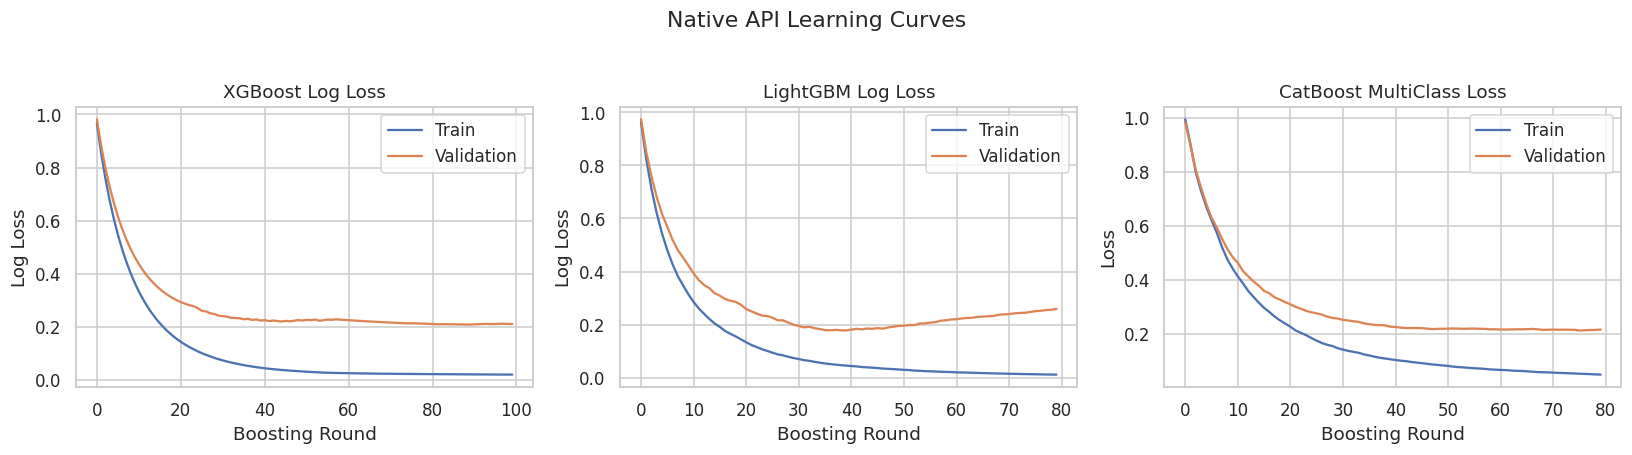

In [12]:
# 1행 3열(가로로 3개) 구조의 서브플롯(그래프 공간)을 생성하고 전체 크기를 설정합니다.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# -------------------------------------------------------------------------
# [첫 번째 그래프: XGBoost]
# -------------------------------------------------------------------------
# 학습 과정에서 기록된 Train 데이터와 Validation 데이터의 mlogloss(로그 손실)를 선 그래프로 그립니다.
axes[0].plot(xgb_eval_result['train']['mlogloss'], label='Train')
axes[0].plot(xgb_eval_result['validation']['mlogloss'], label='Validation')
axes[0].set_title('XGBoost Log Loss')       # 그래프 제목 설정
axes[0].set_xlabel('Boosting Round')        # x축 레이블 설정 (반복 횟수)
axes[0].set_ylabel('Log Loss')              # y축 레이블 설정
axes[0].legend()                            # 범례(Train, Validation 표시) 출력

# -------------------------------------------------------------------------
# [두 번째 그래프: LightGBM]
# -------------------------------------------------------------------------
# 학습 과정에서 기록된 Train 데이터와 Validation 데이터의 multi_logloss를 선 그래프로 그립니다.
axes[1].plot(lgb_eval_result['train']['multi_logloss'], label='Train')
axes[1].plot(lgb_eval_result['validation']['multi_logloss'], label='Validation')
axes[1].set_title('LightGBM Log Loss')      # 그래프 제목 설정
axes[1].set_xlabel('Boosting Round')        # x축 레이블 설정
axes[1].set_ylabel('Log Loss')              # y축 레이블 설정
axes[1].legend()                            # 범례 출력

# -------------------------------------------------------------------------
# [세 번째 그래프: CatBoost]
# -------------------------------------------------------------------------
# CatBoost는 앞선 모델들과 달리 모델 객체 내부에서 직접 학습 이력(.get_evals_result())을 추출합니다.
cb_eval_result = cb_model.get_evals_result()
# CatBoost는 학습 데이터를 'learn', 다중 분류 평가지표를 'MultiClass'라는 키(Key)로 저장합니다.
axes[2].plot(cb_eval_result['learn']['MultiClass'], label='Train')
axes[2].plot(cb_eval_result['validation']['MultiClass'], label='Validation')
axes[2].set_title('CatBoost MultiClass Loss') # 그래프 제목 설정
axes[2].set_xlabel('Boosting Round')          # x축 레이블 설정
axes[2].set_ylabel('Loss')                    # y축 레이블 설정
axes[2].legend()                              # 범례 출력

# -------------------------------------------------------------------------
# [전체 레이아웃 및 출력 설정]
# -------------------------------------------------------------------------
plt.suptitle('Native API Learning Curves', y=1.03) # 3개 그래프를 아우르는 전체 중앙 제목 (y값으로 약간 위쪽에 배치)
plt.tight_layout()                                 # 그래프 요소(축, 제목 등)가 서로 겹치지 않도록 여백을 자동 조절
plt.show()                                         # 최종적으로 완성된 그래프 화면 표시

## 8. Manual Cross Validation

이번에는 **train+val 데이터만** 사용해서 5-Fold CV를 직접 돌립니다.
여기서도 각 라이브러리의 native 문법만 사용합니다.


In [14]:
# 타겟(y)의 클래스 비율을 균등하게 유지하며 데이터를 5개로 나누는 5-Fold 교차 검증 객체를 생성합니다.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 각 Fold별 검증 정확도(Accuracy) 점수를 저장할 빈 리스트들을 선언합니다.
xgb_cv_scores = []
lgb_cv_scores = []
cb_cv_scores = []

# scikit-learn 메서드 중, cross_validate, cross_val_score 사용 불가

# cv.split()을 통해 데이터셋을 학습용(tr_idx)과 검증용(va_idx) 인덱스로 나누며 5번 반복(Loop)합니다.
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_val, y_train_val), start=1):
    # 인덱스(tr_idx, va_idx)를 사용하여 해당 Fold의 학습/검증 데이터를 추출합니다.
    X_tr = X_train_val.iloc[tr_idx]
    X_va = X_train_val.iloc[va_idx]
    y_tr = y_train_val.iloc[tr_idx]
    y_va = y_train_val.iloc[va_idx]

    # -------------------------------------------------------------------------
    # 1. XGBoost 모델 학습 및 평가
    # -------------------------------------------------------------------------
    dtr = xgb.DMatrix(X_tr, label=y_tr)                        # XGBoost 전용 학습 데이터 생성
    dva = xgb.DMatrix(X_va, label=y_va)                        # XGBoost 전용 검증 데이터 생성
    xgb_fold_model = xgb.train(
        params=xgb_params,
        dtrain=dtr,
        num_boost_round=80,
        evals=[(dva, 'validation')],
        verbose_eval=False,
    )
    xgb_fold_pred = np.argmax(xgb_fold_model.predict(dva), axis=1) # 확률 배열에서 가장 높은 클래스 인덱스 추출
    xgb_fold_acc = accuracy_score(y_va, xgb_fold_pred)         # 현재 Fold의 정확도 계산
    xgb_cv_scores.append(xgb_fold_acc)                         # 결과 리스트에 추가

    # -------------------------------------------------------------------------
    # 2. LightGBM 모델 학습 및 평가
    # -------------------------------------------------------------------------
    lgb_tr = lgb.Dataset(X_tr, label=y_tr)                     # LightGBM 전용 학습 데이터 생성
    lgb_va = lgb.Dataset(X_va, label=y_va, reference=lgb_tr)   # LightGBM 전용 검증 데이터 생성
    lgb_fold_model = lgb.train(
        params=lgb_params,
        train_set=lgb_tr,
        num_boost_round=80,
        valid_sets=[lgb_va],
        valid_names=['validation'],
    )
    lgb_fold_pred = np.argmax(lgb_fold_model.predict(X_va), axis=1) # 클래스 예측
    lgb_fold_acc = accuracy_score(y_va, lgb_fold_pred)         # 정확도 계산
    lgb_cv_scores.append(lgb_fold_acc)                         # 결과 리스트에 추가

    # -------------------------------------------------------------------------
    # 3. CatBoost 모델 학습 및 평가
    # -------------------------------------------------------------------------
    cb_tr = Pool(X_tr, y_tr)                                   # CatBoost 전용 학습 데이터 생성
    cb_va = Pool(X_va, y_va)                                   # CatBoost 전용 검증 데이터 생성
    cb_fold_model = CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='MultiClass',
        iterations=80,
        depth=3,
        learning_rate=0.1,
        random_seed=RANDOM_STATE,
        verbose=False,
    )
    cb_fold_model.fit(cb_tr, eval_set=cb_va, use_best_model=False)
    cb_fold_pred = cb_fold_model.predict(cb_va).reshape(-1).astype(int) # 1차원 정수형으로 예측 클래스 변환
    cb_fold_acc = accuracy_score(y_va, cb_fold_pred)           # 정확도 계산
    cb_cv_scores.append(cb_fold_acc)                           # 결과 리스트에 추가

    # 현재 Fold의 검증 결과를 출력합니다.
    print(f'Fold {fold} | XGB={xgb_fold_acc:.4f} | LGBM={lgb_fold_acc:.4f} | CAT={cb_fold_acc:.4f}')

# 5번의 Fold 학습이 완료된 후, 각 모델의 최종 평균 교차 검증(CV) 정확도를 계산하여 출력합니다.
print()
print('XGBoost CV mean accuracy :', round(np.mean(xgb_cv_scores), 4))
print('LightGBM CV mean accuracy:', round(np.mean(lgb_cv_scores), 4))
print('CatBoost CV mean accuracy:', round(np.mean(cb_cv_scores), 4))

Fold 1 | XGB=0.9583 | LGBM=0.9583 | CAT=0.9583
Fold 2 | XGB=1.0000 | LGBM=1.0000 | CAT=1.0000
Fold 3 | XGB=0.9583 | LGBM=0.9583 | CAT=0.9583
Fold 4 | XGB=0.9167 | LGBM=1.0000 | CAT=0.9583
Fold 5 | XGB=0.9167 | LGBM=0.9167 | CAT=0.9167

XGBoost CV mean accuracy : 0.95
LightGBM CV mean accuracy: 0.9667
CatBoost CV mean accuracy: 0.9583


## 9. Final Summary

In [15]:
# 각 모델별 평가 지표(검증 정확도, 테스트 정확도, 교차 검증 평균 정확도)를 딕셔너리 구조로 묶어 DataFrame을 생성합니다.
summary = pd.DataFrame({
    'model': ['XGBoost native', 'LightGBM native', 'CatBoost native'], # 비교 대상 모델 이름 리스트

    # 홀드아웃(Hold-out) 검증 세트(X_val, y_val)에 대한 각 모델의 정확도 점수 리스트
    'validation_accuracy': [
        accuracy_score(y_val, xgb_val_pred),  # XGBoost 검증 정확도
        accuracy_score(y_val, lgb_val_pred),  # LightGBM 검증 정확도
        accuracy_score(y_val, cb_val_pred),   # CatBoost 검증 정확도
    ],

    # 최종 평가용 테스트 세트(X_test, y_test)에 대한 각 모델의 정확도 점수 리스트
    'test_accuracy': [
        accuracy_score(y_test, xgb_test_pred),# XGBoost 테스트 정확도
        accuracy_score(y_test, lgb_test_pred),# LightGBM 테스트 정확도
        accuracy_score(y_test, cb_test_pred), # CatBoost 테스트 정확도
    ],

    # 5-Fold 교차 검증 과정에서 저장된 각 Fold별 점수의 평균(mean) 값 리스트
    'cv_mean_accuracy': [
        np.mean(xgb_cv_scores),                # XGBoost 5-Fold CV 평균 정확도
        np.mean(lgb_cv_scores),                # LightGBM 5-Fold CV 평균 정확도
        np.mean(cb_cv_scores),                 # CatBoost 5-Fold CV 평균 정확도
    ],
})

# 생성된 표(DataFrame)의 모든 수치 데이터(확률 및 점수)를 소수점 넷째 자리까지 반올림하여 깔끔하게 출력합니다.
summary.round(4)

,model,validation_accuracy,test_accuracy,cv_mean_accuracy
0,XGBoost native,0.9333,0.9333,0.9500
1,LightGBM native,0.9333,0.8667,0.9667
2,CatBoost native,0.9333,0.9333,0.9583


# 옵션 : 과적합 방지

▼ [모델 1] 조기 종료 발동 시점 (Best Iteration): 93
XGBoost 최종 Test 정확도 (조기종료 적용): 0.9333


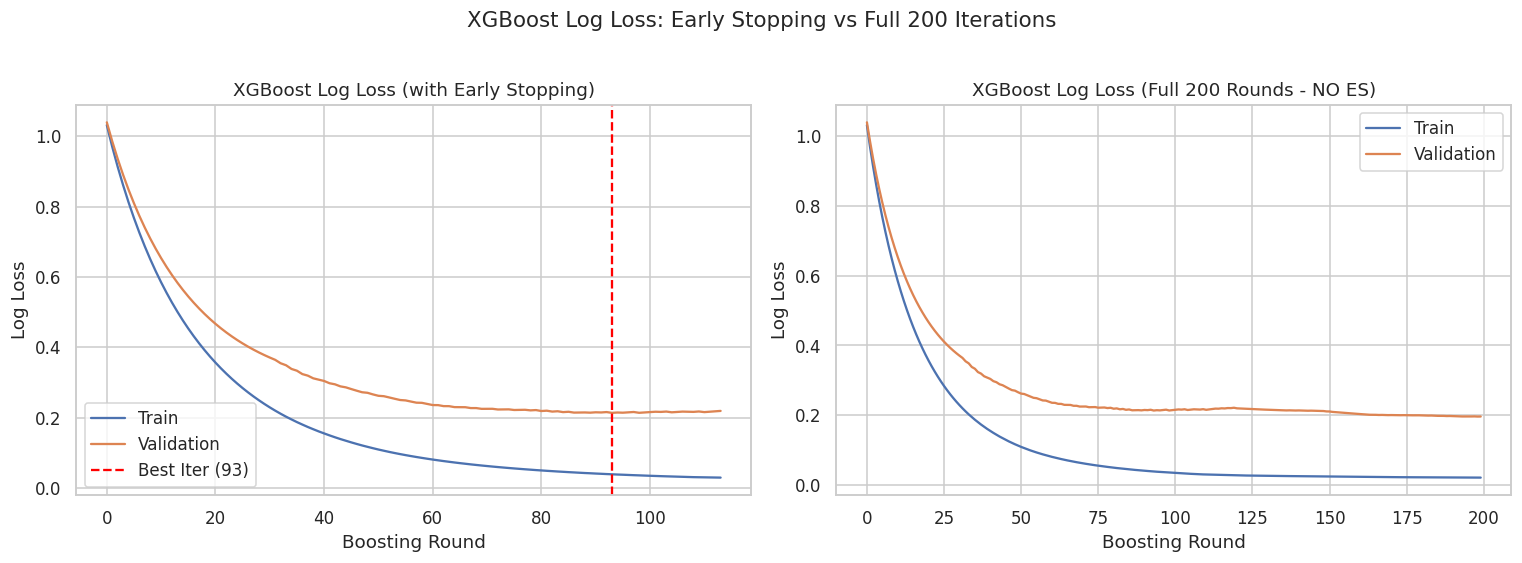

In [16]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

# -------------------------------------------------------------------------
# [1단계] 초기 환경 설정 및 데이터 로드/분할
# -------------------------------------------------------------------------
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

iris = load_iris(as_frame=True)
X = iris.data.copy()
y = iris.target.copy()

# 데이터 분할 (Train 60% / Val 20% / Test 20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_val
)

# XGBoost 전용 DMatrix 생성
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# 과적합 방지용 기본 파라미터 설정
xgb_params = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'eval_metric': ['merror', 'mlogloss'],
    'max_depth': 2,
    'eta': 0.05,
    'seed': RANDOM_STATE,
}

# -------------------------------------------------------------------------
# [2단계] 모델 1: 조기 종료(Early Stopping) 적용 모델 학습
# -------------------------------------------------------------------------
xgb_eval_result_es = {}
xgb_model_es = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=200,
    evals=[(dtrain, 'train'), (dval, 'validation')],
    evals_result=xgb_eval_result_es,
    early_stopping_rounds=20,      # 개선 없으면 도중에 중단 (기록도 여기서 끊김)
    verbose_eval=False,
)

# -------------------------------------------------------------------------
# [3단계] 모델 2: 조기 종료 없이 200라운드 끝까지(Full) 학습하는 모델
# -------------------------------------------------------------------------
xgb_eval_result_full = {}
xgb_model_full = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=200,           # early_stopping_rounds 옵션을 제외하여 200까지 강제 진행
    evals=[(dtrain, 'train'), (dval, 'validation')],
    evals_result=xgb_eval_result_full,
    verbose_eval=False,
)

# 결과 출력
print(f"▼ [모델 1] 조기 종료 발동 시점 (Best Iteration): {xgb_model_es.best_iteration}")
xgb_test_pred_proba = xgb_model_es.predict(dtest)
xgb_test_pred = np.argmax(xgb_test_pred_proba, axis=1)
print('XGBoost 최종 Test 정확도 (조기종료 적용):', round(accuracy_score(y_test, xgb_test_pred), 4))

# -------------------------------------------------------------------------
# [4단계] 1행 2열(ncols=2) 서브플롯 학습 곡선 시각화 (모델 1 vs 모델 2)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# 1) 왼쪽 그래프: 모델 1의 조기 종료된 Log Loss (x축이 도중에 끊김)
axes[0].plot(xgb_eval_result_es['train']['mlogloss'], label='Train')
axes[0].plot(xgb_eval_result_es['validation']['mlogloss'], label='Validation')
axes[0].axvline(xgb_model_es.best_iteration, color='red', linestyle='--', label=f'Best Iter ({xgb_model_es.best_iteration})')
axes[0].set_title('XGBoost Log Loss (with Early Stopping)')
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('Log Loss')
axes[0].legend()

# 2) 오른쪽 그래프: 모델 2의 200라운드 끝까지 달린 Log Loss (x축이 200까지 채워짐)
axes[1].plot(xgb_eval_result_full['train']['mlogloss'], label='Train')
axes[1].plot(xgb_eval_result_full['validation']['mlogloss'], label='Validation')
axes[1].set_title('XGBoost Log Loss (Full 200 Rounds - NO ES)')
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('Log Loss')
axes[1].legend()

# 전체 레이아웃 정돈
plt.suptitle('XGBoost Log Loss: Early Stopping vs Full 200 Iterations', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()